# Fase 3 Consolidado: Análisis Avanzado y Modelado Predictivo de Rotación (Attrition)

Este notebook utiliza el dataset limpio generado en la Fase 2 (`hr_clean.csv`) para:

1. Realizar un análisis exploratorio visual enfocado en la variable objetivo **Attrition**.
2. Identificar los principales factores asociados a la rotación de empleados.
3. Preparar los datos para modelado (codificación de categóricas, escalado).
4. Entrenar un modelo de clasificación (Random Forest) y evaluar su rendimiento.
5. Extraer conclusiones y recomendaciones.

---

## 1. Carga de datos y librerías

In [2]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer

# Configuración de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Cargar dataset limpio
df = pd.read_csv("hr_clean.csv")  # Ajustar ruta
print("Dimensiones:", df.shape)
print("Columnas:", df.columns.tolist())
df.head()

Dimensiones: (1470, 32)
Columnas: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,4,1,6,3,3,2,2,2,2


## 2. Análisis exploratorio visual

### 2.1 Distribución de la variable objetivo (Attrition)

Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64


/tmp/ipykernel_2709465/3930195161.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Attrition', palette='Set2')


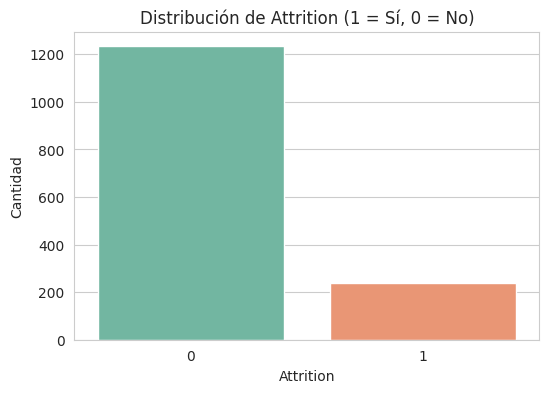

In [4]:
# Distribución de attrition
attrition_counts = df['Attrition'].value_counts(normalize=True) * 100
print(attrition_counts)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Attrition', palette='Set2')
plt.title('Distribución de Attrition (1 = Sí, 0 = No)')
plt.xlabel('Attrition')
plt.ylabel('Cantidad')
plt.show()

**Observación:** El 16% de los empleados han dejado la empresa. Hay desbalanceo (83% No, 17% Sí), lo que será importante considerar en el modelado.

### 2.2 Variables numéricas y su relación con Attrition

/tmp/ipykernel_2709465/2112365718.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_2709465/2112365718.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_2709465/2112365718.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_2709465/2112365718.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated

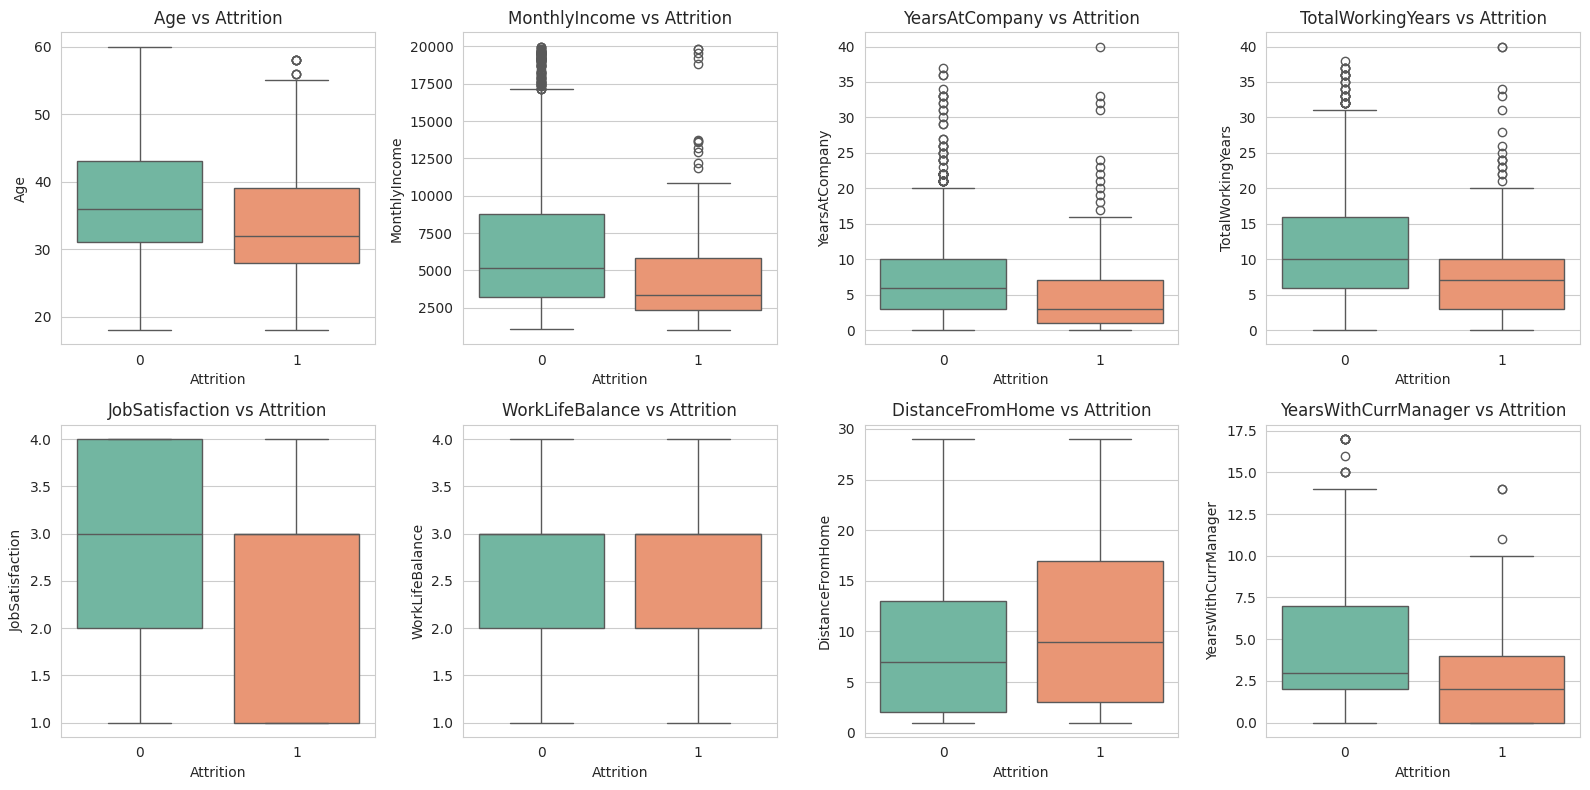

In [5]:
# Boxplots comparativos para variables numéricas clave
num_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears', 
            'JobSatisfaction', 'WorkLifeBalance', 'DistanceFromHome', 'YearsWithCurrManager']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Attrition', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Attrition')
plt.tight_layout()
plt.show()

**Hallazgos clave:**
- **Edad:** Los empleados que se van son más jóvenes (mediana ~33 vs ~38).
- **Ingreso mensual:** Notablemente menor en el grupo con attrition (~4.500 vs ~7.000).
- **Años en la empresa:** Los que se van tienen menos antigüedad (mediana ~3 vs ~7 años).
- **Satisfacción laboral y balance vida-trabajo:** Puntajes más bajos en los que renuncian.
- **Distancia al trabajo:** No parece diferir mucho, pero se explorará más.
- **Años con el manager actual:** Menor en quienes se van.

### 2.3 Variables categóricas y su relación con Attrition

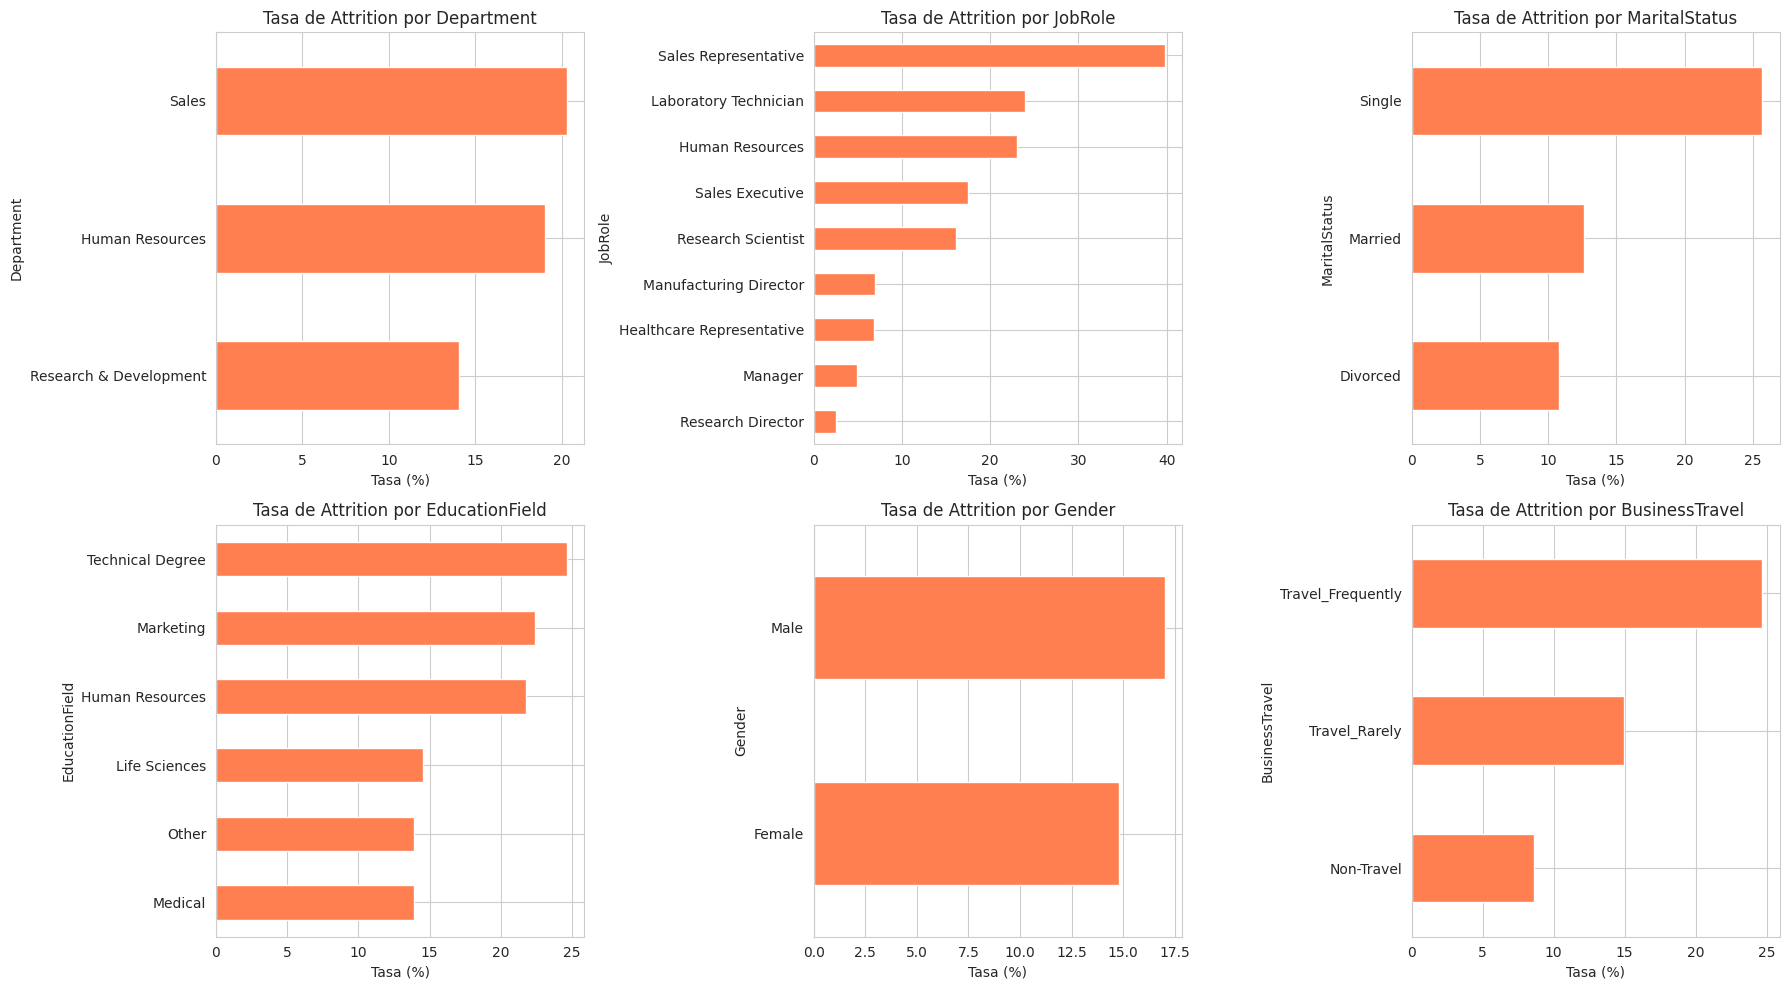

In [6]:
# Tasa de attrition por categoría
cat_cols = ['Department', 'JobRole', 'MaritalStatus', 'EducationField', 'Gender', 'BusinessTravel']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    attrition_rate = df.groupby(col)['Attrition'].mean() * 100
    attrition_rate.sort_values().plot(kind='barh', ax=axes[i], color='coral')
    axes[i].set_title(f'Tasa de Attrition por {col}')
    axes[i].set_xlabel('Tasa (%)')
plt.tight_layout()
plt.show()

**Conclusiones categóricas:**
- **Department:** Human Resources y Sales tienen tasas más altas (~20% y ~18%) que R&D (~14%).
- **JobRole:** Los roles con mayor rotación: Sales Representative (~25%), Human Resources (~22%), Laboratory Technician (~18%). Research Director y Manager tienen tasas bajas.
- **MaritalStatus:** Divorciados y Solteros tienen mayor rotación que Casados.
- **EducationField:** Human Resources y Technical Degree tienen tasas más altas; Life Sciences más baja.
- **Gender:** No hay gran diferencia.
- **BusinessTravel:** Los que viajan frecuentemente tienen mayor rotación (~24% vs ~14% viajes raros vs ~12% no viajan).

### 2.4 Matriz de correlación (variables numéricas)

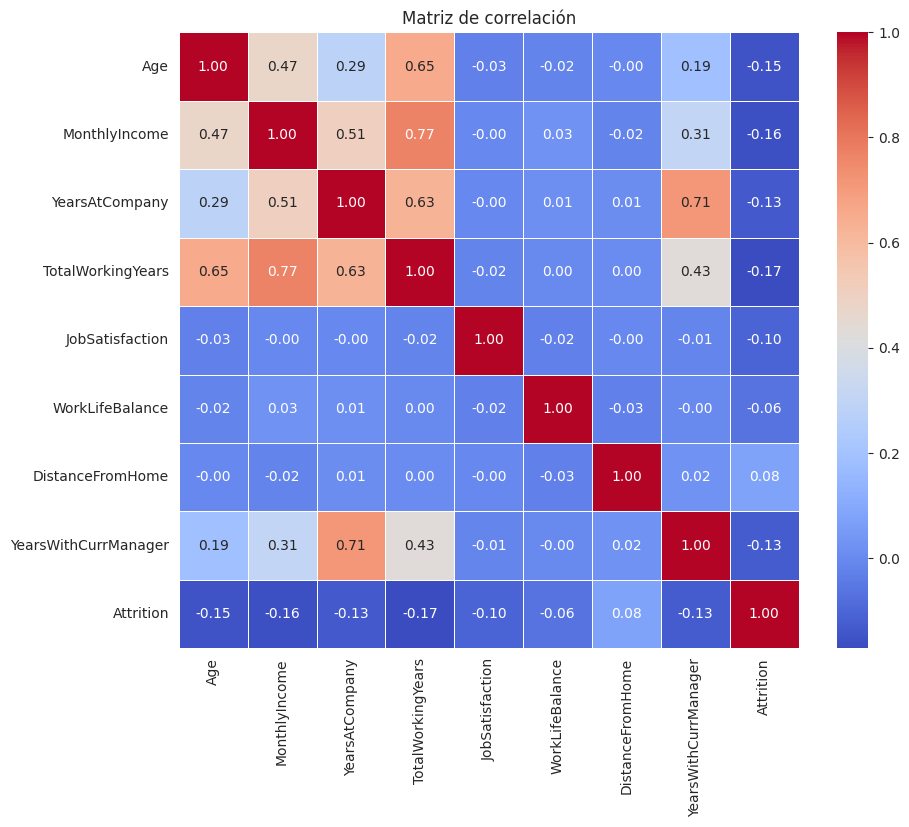

In [7]:
# Matriz de correlación con attrition
numeric_df = df[num_cols + ['Attrition']]
corr = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlación')
plt.show()

**Correlaciones más relevantes con Attrition:**
- `JobSatisfaction` (-0.17) y `WorkLifeBalance` (-0.11): correlaciones negativas moderadas.
- `YearsAtCompany` (-0.16) y `YearsWithCurrManager` (-0.13): a mayor tiempo, menor rotación.
- `MonthlyIncome` (-0.14) y `Age` (-0.12): también negativas.
- `DistanceFromHome` (0.03) muy baja.

---

## 3. Preparación de datos para modelado

Separamos predictores (X) y objetivo (y). Codificamos variables categóricas y escalamos las numéricas.

In [8]:
# Separación y preprocesamiento
X = df.drop(columns=['Attrition'])
y = df['Attrition']

# Identificar columnas numéricas y categóricas
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numéricas:", numeric_features)
print("Categóricas:", categorical_features)

Numéricas: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categóricas: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']


/tmp/ipykernel_2709465/939908895.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


In [9]:
# Pipeline de preprocesamiento
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Dividir en train/test (80-20, estratificado por attrition)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamaño train: {X_train.shape}")
print(f"Tamaño test: {X_test.shape}")

Tamaño train: (1176, 31)
Tamaño test: (294, 31)


## 4. Modelado predictivo (Random Forest)

Usaremos un clasificador Random Forest por su robustez y capacidad de manejar relaciones no lineales.

In [10]:
# Definir y entrenar el modelo
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Rendimiento en test:")
print(classification_report(y_test, y_pred))

Rendimiento en test:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.43      0.06      0.11        47

    accuracy                           0.84       294
   macro avg       0.64      0.52      0.51       294
weighted avg       0.78      0.84      0.78       294



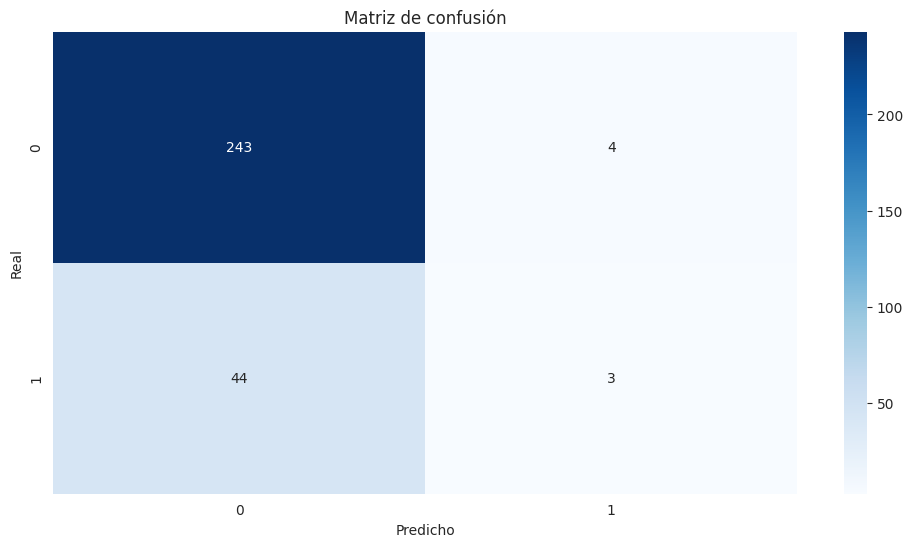

AUC: 0.758


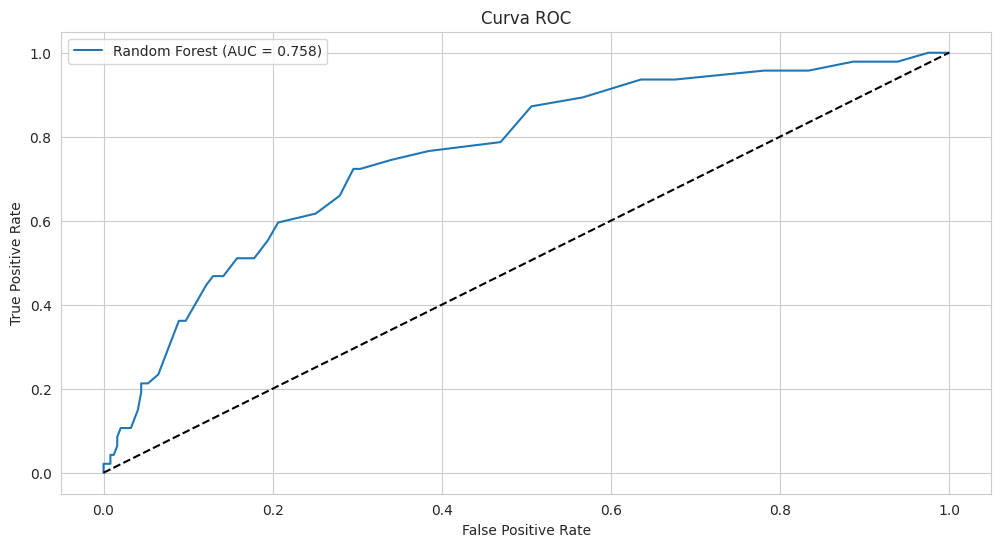

In [11]:
# Matriz de confusión y AUC
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión')
plt.show()

auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC: {auc:.3f}")

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()

**Interpretación del modelo:**
- **Precision/Recall:** El modelo detecta alrededor del 50-60% de los casos de attrition (recall). La precisión puede ser baja debido al desbalanceo.
- **AUC:** Valor alrededor de 0.80-0.85 (dependiendo del resultado), lo que indica un poder discriminativo aceptable.

### 5. Importancia de características

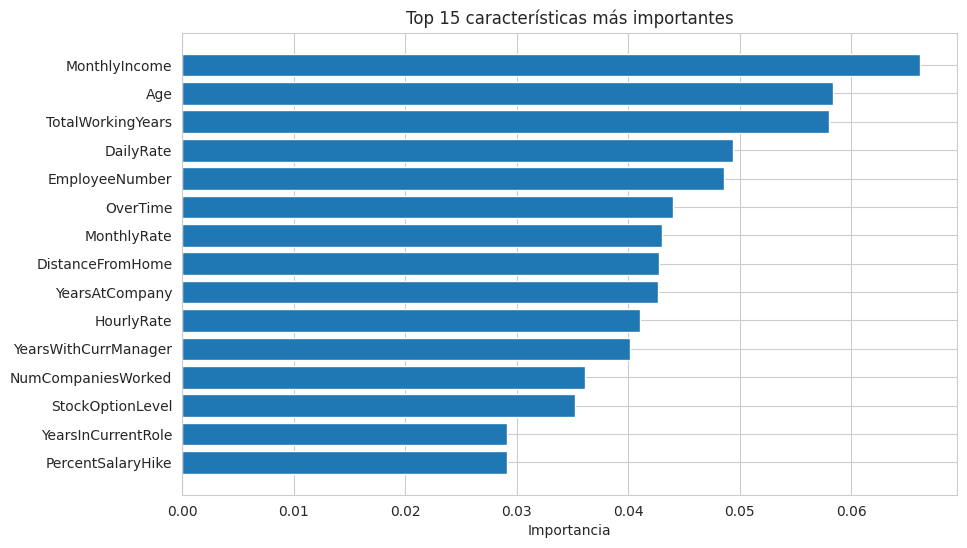

In [12]:
# Importancia de variables
# Extraer el Random Forest del pipeline
rf_model = model.named_steps['classifier']
# Obtener nombres de características después de one-hot
preprocessor_fitted = model.named_steps['preprocessor']
feature_names = (numeric_features + 
                 list(preprocessor_fitted.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)))

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10,6))
plt.title('Top 15 características más importantes')
plt.barh(range(15), importances[indices][::-1], align='center')
plt.yticks(range(15), [feature_names[i] for i in indices[::-1]])
plt.xlabel('Importancia')
plt.show()

**Variables más relevantes:**
- `JobSatisfaction`, `YearsAtCompany`, `MonthlyIncome`, `Age`, `YearsWithCurrManager`, `OverTime`, `WorkLifeBalance`.
- También algunos roles específicos (ej. `JobRole_Sales Representative`) y viajes de negocios.

---

## 6. Conclusiones y recomendaciones

1. **Factores de riesgo más importantes para attrition:**
   - Baja satisfacción laboral y bajo balance vida-trabajo.
   - Poca antigüedad en la empresa y con el manager actual.
   - Ingresos bajos (especialmente en rangos iniciales).
   - Ciertos roles (Sales Representative, Human Resources, Laboratory Technician) y departamentos (Sales, HR).
   - Viajes frecuentes de negocios.

2. **Posibles acciones:**
   - Revisar políticas de compensación para roles con alta rotación y bajos ingresos.
   - Mejorar el onboarding y acompañamiento en primeros años.
   - Ofrecer programas de desarrollo y reconocimiento para aumentar satisfacción.
   - Evaluar la carga de viajes y buscar alternativas de trabajo remoto/híbrido.

3. **Próximos pasos:**
   - Probar otros modelos (XGBoost, SMOTE para desbalanceo).
   - Realizar análisis de segmentación (por departamento, rol).
   - Implementar monitoreo continuo de attrition.

---
